In [1]:
#load packages needed in this notebook
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import os
from eofs.standard import Eof
import regionmask
import cartopy.crs as ccrs
from matplotlib import pyplot as PP
import copy
import matplotlib as mpl
import matplotlib.patches as mpatches
from cartopy.util import add_cyclic_point

ERROR 1: PROJ: proj_create_from_database: Open of /glade/u/home/nmaher/.conda/envs/clara/share/proj failed


In [2]:
#deinfe models used in this figure and when the start year is
models=['CESM2','CESM1-LE','ACCESS-SSP370','CanESM5-SSP370','GFDL-SPEAR','IPSL-CM6A','MIROC6','MPI-GE']

#1950-2015
#tell me when the start year is 
syear=[1850,1920,1850,1850,1921,1850,1850,1850]
#offset=1920-syear

#load lon lat should be same for all models
outputdira='/glade/campaign/cgd/cas/nmaher/cesm1_lens/Amon/zg/' 
ds_fx = xr.open_dataset(outputdira+'zg_Amon_CESM1-CAM5_historical_rcp85_r10i1p1_192001-210012_g025.nc')

lon = ds_fx.lon
lat = ds_fx.lat


In [3]:
#load data
outputdir_figD='/glade/work/nmaher/SEOF_output/Fig_data/'



In [4]:
cdataE_tot=np.zeros([9,6,72,145])


In [5]:
#load the observations

models2=['OBS']
for model in models2:

    eof_T='_FS1bdata_zgNPac'
    with np.load(outputdir_figD+model+eof_T+'.npz') as npz:
        data_z500_npac = np.ma.MaskedArray(**npz)
    
    eof_T='_FS1bdata_zgNAt'
    with np.load(outputdir_figD+model+eof_T+'.npz') as npz:
        data_z500_nat = np.ma.MaskedArray(**npz)

In [6]:
#define the atlantic mask

lat_bounds=[20,90]
lon_bounds=[280,360]
lon_bounds2=[0,10]

lons=lon
lats=lat

data_z500_nat2=np.zeros([72,144])
coslat=np.cos(np.deg2rad(lats))
for i in range(144):
    data_z500_nat2[:,i]=np.squeeze(data_z500_nat[:,:,i])*coslat

if lat_bounds:
    lat_mask = (lats >= lat_bounds[0]) & (lats <= lat_bounds[1])
else:
    lat_mask = np.ones_like(lats, dtype=bool)


if lon_bounds and lon_bounds2:
    lon_mask = (
        ((lons >= lon_bounds[0]) & (lons <= lon_bounds[1])) |
        ((lons >= lon_bounds2[0]) & (lons <= lon_bounds2[1]))
    )
else:
    lon_mask = np.ones_like(lons, dtype=bool)

obs_z500_nat2 = data_z500_nat2[np.ix_(lat_mask, lon_mask)]

#out=np.corrcoef(data_z500_nat2.flatten(),data_z500_nat2.flatten(),rowvar=False)

In [7]:
#define the north pacific mask

lat_boundsP=[20,90]
lon_boundsP=[110,260]

data_z500_npac2=np.zeros([3,72,144])
obs_z500_npac2=np.zeros([3,28,60])

coslat=np.cos(np.deg2rad(lats))
for i in range(144):
    for j in range(3):
        data_z500_npac2[j,:,i]=np.squeeze(data_z500_npac[j,:,i])*coslat

if lat_boundsP:
    lat_maskP = (lats >= lat_boundsP[0]) & (lats <= lat_boundsP[1])
else:
    lat_maskP = np.ones_like(lats, dtype=bool)


if lon_boundsP:
    lon_maskP = (lons >= lon_boundsP[0]) & (lons <= lon_boundsP[1])
    
else:
    lon_maskP = np.ones_like(lons, dtype=bool)

for j in range(3):
    tmp=np.squeeze(data_z500_npac2[j,:,:])
    obs_z500_npac2[j,:,:] = tmp[np.ix_(lat_maskP, lon_maskP)]


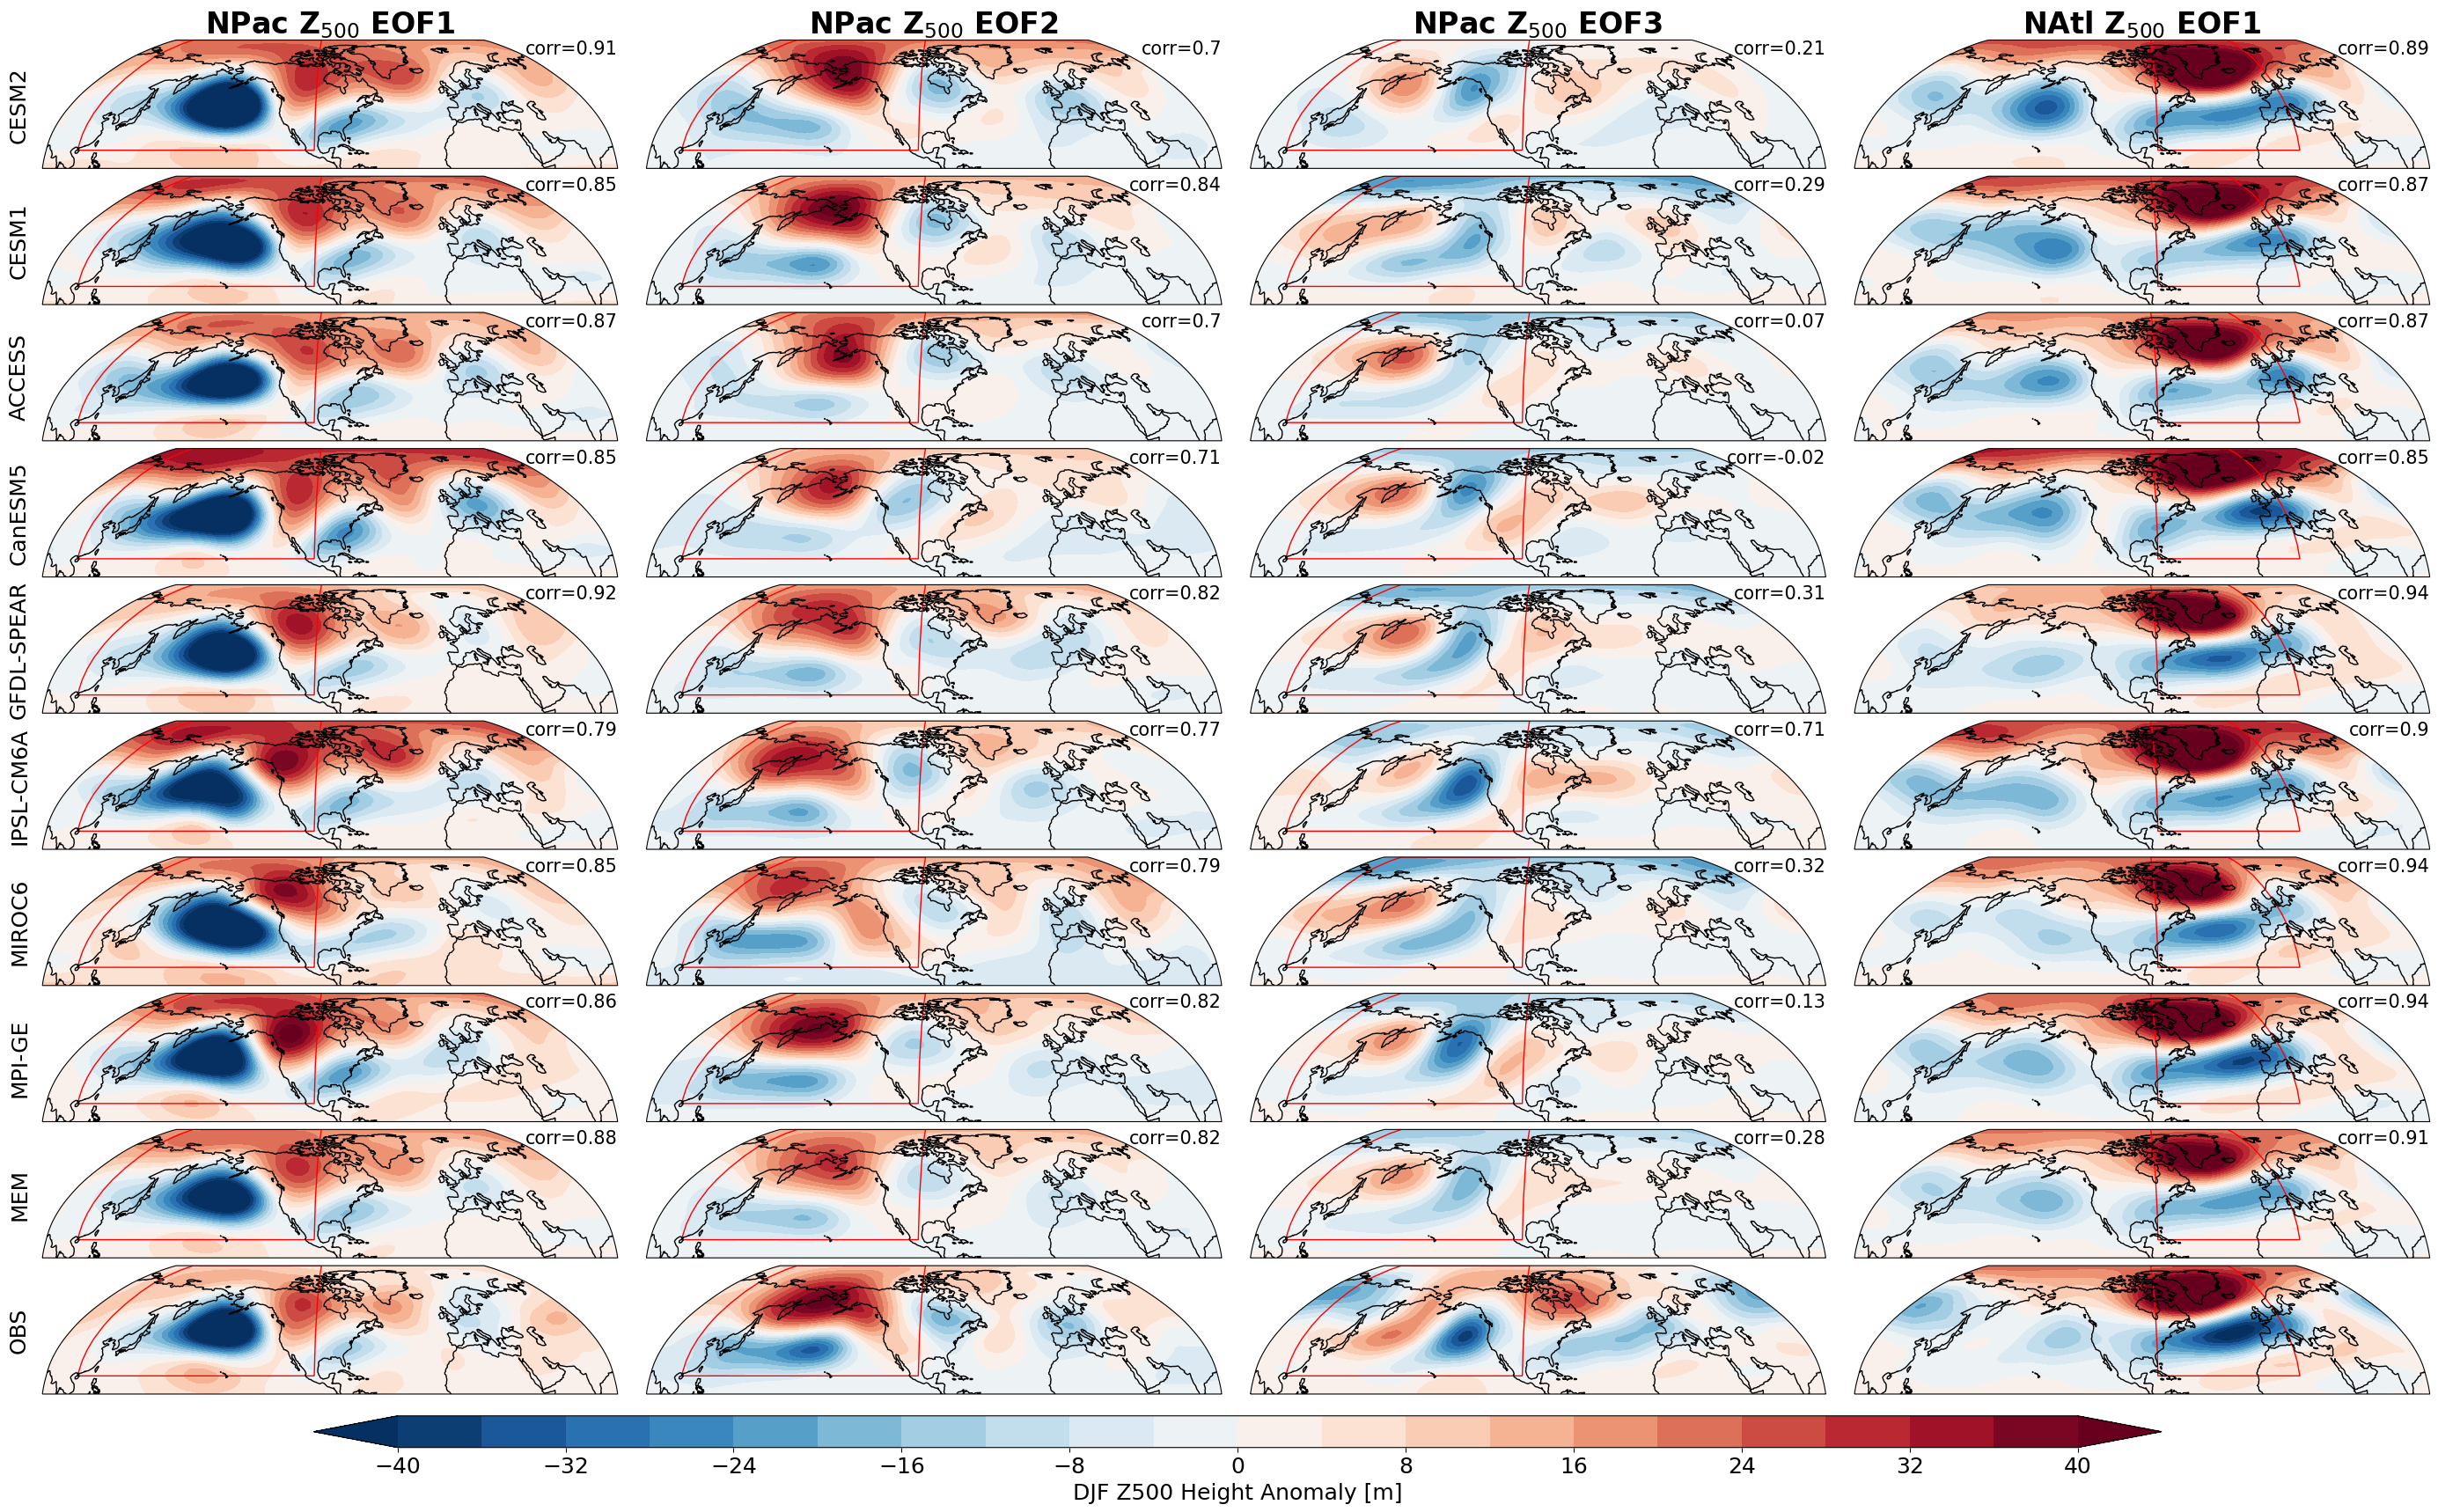

In [10]:
#plot

models_title=['CESM2','CESM1','ACCESS','CanESM5','GFDL-SPEAR','IPSL-CM6A','MIROC6','MPI-GE']


#plot data
fig,axs = PP.subplots(10,4,figsize=(35,20), subplot_kw={'projection': ccrs.Robinson(central_longitude=270)})

levelsS = np.linspace(0,15)
levelsS2 = np.linspace(0,100)

levels = np.linspace(-40,40,21)
clevels = np.linspace(-40,40,11)

cmap2=copy.deepcopy(mpl.cm.plasma)

e=[-180, 180,10,90]

cmap = copy.deepcopy(mpl.cm.RdBu_r)

# define 2d lat and lon points for ploting sig locs
lons=lon
lats=lat
lon2d,lat2d = np.meshgrid(lons,lats)

ii=-1
for model in models:
    ii=ii+1
    offset=1921-syear[ii]

    eof_T='_FS1bdata_zgNPac_time'
    with np.load(outputdir_figD+model+eof_T+'.npz') as npz:
        data_z500_npac = np.ma.MaskedArray(**npz)
    if model=='CESM2':
        data_z500_npac[2,:,...]=data_z500_npac[2,:,...]*-1
        
    
    eof_T='_FS1bdata_zgTPac_time'
    with np.load(outputdir_figD+model+eof_T+'.npz') as npz:
        data_z500_tpac = np.ma.MaskedArray(**npz)
    
    eof_T='_FS1bdata_zgNAt_time'
    with np.load(outputdir_figD+model+eof_T+'.npz') as npz:
        data_z500_nat = np.ma.MaskedArray(**npz)
    

    cnt=0
    ii2=-1
    for i in range(3): 

        ii2=ii2+1
        # grab early data
        cdataE,clons = add_cyclic_point(data_z500_npac[i,:,...].mean(axis=0),lons)
        # grab late data
        temp=data_z500_npac[i,:,...].mean(axis=0)
        data_z500_npac2 = temp[np.ix_(lat_maskP, lon_maskP)]
        temp2=obs_z500_npac2[i,:,:]
        corr=np.corrcoef(temp2.flatten(),data_z500_npac2.flatten(),rowvar=False)
        #print(corr[0,1])
        axs[ii,i].text(1, 1, 'corr='+str(round(corr[0,1],2)),horizontalalignment='right',verticalalignment='top',transform=axs[ii,i].transAxes,fontsize=15)

        #plot difference in colour and early in contours
        cplt = axs[ii,i].contourf(clons,lats,cdataE, transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extent=e, extend='both')   

        axs[ii,i].coastlines()
        #axs[ii,i].set_ylim(-90,90)
        axs[ii,i].set_extent([-180, 180, 10, 90], crs=ccrs.PlateCarree())

        cdataE_tot[ii,ii2,:,:]=cdataE
    
    for i in range(1): 
        ii2=ii2+1
        # grab early data
        cdataE,clons = add_cyclic_point(data_z500_nat[i,:,...].mean(axis=0),lons)
        # grab late data
        
        temp=data_z500_nat[i,:,...].mean(axis=0)
        data_z500_nat2 = temp[np.ix_(lat_mask, lon_mask)]
        temp2=obs_z500_nat2
        corr=np.corrcoef(temp2.flatten(),data_z500_nat2.flatten(),rowvar=False)
        #print(corr[0,1])
        axs[ii,i+3].text(1, 1, 'corr='+str(round(corr[0,1],2)),horizontalalignment='right',verticalalignment='top',transform=axs[ii,i+3].transAxes,fontsize=15)

        #plot difference in colour and early in contours
        cplt = axs[ii,i+3].contourf(clons,lats,cdataE, transform=ccrs.PlateCarree(), levels=levels, extent=e, cmap=cmap, extend='both')   

        axs[ii,i+3].coastlines()
        #axs[ii,i+3].set_ylim(-90,90)
        axs[ii,i+3].set_extent([-180, 180, 10, 90], crs=ccrs.PlateCarree())
 
        cdataE_tot[ii,ii2,:,:]=cdataE
  



ii=8
ii2=-1
for i in range(4): 
        ii2=ii2+1

        cdataE=np.mean(cdataE_tot[:,ii2,:,:],axis=0)

        if i <3:
            data_z500_npac2 = cdataE[np.ix_(lat_maskP, lon_maskP)]
            temp2=obs_z500_npac2[i,:,:]
        else:
            data_z500_npac2 = cdataE[np.ix_(lat_mask, lon_mask)]
            temp2=obs_z500_nat2
            
        corr=np.corrcoef(temp2.flatten(),data_z500_npac2.flatten(),rowvar=False)
        #print(corr[0,1])
        axs[ii,i].text(1, 1, 'corr='+str(round(corr[0,1],2)),horizontalalignment='right',verticalalignment='top',transform=axs[ii,i].transAxes,fontsize=15)

    
        #plot difference in colour and early in contours
        cplt = axs[ii,i].contourf(clons,lats,cdataE, transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extent=e, extend='both')   

        axs[ii,i].coastlines()
        #axs[ii,i].set_ylim(-90,90)
        axs[ii,i].set_extent([-180, 180, 10, 90], crs=ccrs.PlateCarree())


ii=9
models2=['OBS']
for model in models2:

    eof_T='_FS1bdata_zgNPac'
    with np.load(outputdir_figD+model+eof_T+'.npz') as npz:
        data_z500_npac = np.ma.MaskedArray(**npz)
    
    eof_T='_FS1bdata_zgNAt'
    with np.load(outputdir_figD+model+eof_T+'.npz') as npz:
        data_z500_nat = np.ma.MaskedArray(**npz)
    

    cnt=0
    ii2=-1
    for i in range(3): 

        ii2=ii2+1
        # grab early data
        cdataE,clons = add_cyclic_point(data_z500_npac[i,:,:],lons)
        # grab late data

        #plot difference in colour and early in contours
        cplt = axs[ii,i].contourf(clons,lats,cdataE, transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extent=e, extend='both')   

        axs[ii,i].coastlines()
        #axs[ii,i].set_ylim(-90,90)
        axs[ii,i].set_extent([-180, 180, 10, 90], crs=ccrs.PlateCarree())

    
    for i in range(1): 
        ii2=ii2+1
        # grab early data
        cdataE,clons = add_cyclic_point(data_z500_nat[i,:,:],lons)
        # grab late data

        #plot difference in colour and early in contours
        cplt = axs[ii,i+3].contourf(clons,lats,cdataE, transform=ccrs.PlateCarree(), levels=levels, extent=e, cmap=cmap, extend='both')   

        axs[ii,i+3].coastlines()
        #axs[ii,i+3].set_ylim(-90,90)
        axs[ii,i+3].set_extent([-180, 180, 10, 90], crs=ccrs.PlateCarree())
 
  




PP.subplots_adjust(hspace=0.05,wspace=0.05)
cticks = np.linspace(-1,1,21)
cbar_ax = fig.add_axes([0.213, 0.08, 0.6, 0.018])
cbar = fig.colorbar(cplt, cax=cbar_ax, orientation='horizontal', ticks=levels[::2])
cbar.set_label('DJF Z500 Height Anomaly [m]',fontsize=18)
cbar.ax.tick_params(labelsize=18)




PP.text(-0.04,0.5,models_title[0], rotation=90, fontsize=18, ha='center', va='center', transform=axs[0,0].transAxes)
PP.text(-0.04,0.5,models_title[1], rotation=90, fontsize=18, ha='center', va='center', transform=axs[1,0].transAxes)
PP.text(-0.04,0.5,models_title[2], rotation=90, fontsize=18, ha='center', va='center', transform=axs[2,0].transAxes)
PP.text(-0.04,0.5,models_title[3], rotation=90, fontsize=18, ha='center', va='center', transform=axs[3,0].transAxes)
PP.text(-0.04,0.5,models_title[4], rotation=90, fontsize=18, ha='center', va='center', transform=axs[4,0].transAxes)
PP.text(-0.04,0.5,models_title[5], rotation=90, fontsize=18, ha='center', va='center', transform=axs[5,0].transAxes)
PP.text(-0.04,0.5,models_title[6], rotation=90, fontsize=18, ha='center', va='center', transform=axs[6,0].transAxes)
PP.text(-0.04,0.5,models_title[7], rotation=90, fontsize=18, ha='center', va='center', transform=axs[7,0].transAxes)
PP.text(-0.04,0.5,'MEM', rotation=90, fontsize=18, ha='center', va='center', transform=axs[8,0].transAxes)
PP.text(-0.04,0.5,'OBS', rotation=90, fontsize=18, ha='center', va='center', transform=axs[9,0].transAxes)



axs[0,0].set_title('NPac Z$_{500}$ EOF1', fontsize=24, weight='bold')
axs[0,1].set_title('NPac Z$_{500}$ EOF2', fontsize=24, weight='bold')
axs[0,2].set_title('NPac Z$_{500}$ EOF3', fontsize=24, weight='bold')
axs[0,3].set_title('NAtl Z$_{500}$ EOF1', fontsize=24, weight='bold')












# draw NPac Bnds

lat_range=[20,90]
lon_range=[110,260]
lat_height = lat_range[-1]-lat_range[0]
lon_width = lon_range[-1]-lon_range[0]

for i in range(3):
    for j in range(10):

        # NPac bnds
        axs[j,i].add_patch(mpatches.Rectangle(xy=[lon_range[0],lat_range[0]], width=lon_width, height=lat_height,\
                                edgecolor='red',\
                                linewidth=1,\
                                alpha=1,\
                                fill=False,\
                                transform=ccrs.PlateCarree()))

# draw NAtl Bnds

lat_range=[20,90]
lon_range=[280,10]

lat_height = lat_range[-1]-lat_range[0]
lon_width = lon_range[-1]-lon_range[0]+360

for i in range(1):
    for j in range(10):
        # NAtl bnds
        axs[j,i+3].add_patch(mpatches.Rectangle(xy=[lon_range[0],lat_range[0]], width=lon_width, height=lat_height,\
                                edgecolor='red',\
                                linewidth=1,\
                                alpha=1,\
                                fill=False,\
                                transform=ccrs.PlateCarree()))


outputdir2='/glade/work/nmaher/SEOF_output/figs_final/revision/'
PP.savefig(outputdir2+'Figure3', dpi=300, bbox_inches='tight')
PP.show()
